# 3. Area Of Interest

Tutorial 2 narrowed the data by *value* and by *label*. This one narrows it by
**geography**: a box, a circle, a polygon, or a vertical cross-section.

| method | AOI | typical use |
|---|---|---|
| `crop_by_bbox` | rectangle | a map tile, a model domain |
| `crop_around_point` | circle | everything within N km of a place |
| `crop_by_polygone` | any polygon | a catchment, a shapefile |
| `extract_cross_section` | a line + beam width | a vertical slice through a storm |

The first three keep the gates and drop the rest. The fourth also computes, for
every selected gate, its position **along the line** and its **altitude** (the
geometry a vertical cross-section plot needs).

---
## One rule about the crs

Every AOI runs in the **archive's own CRS**, read from `info.yaml`. You never have
to restate it. What you *do* have to say is which CRS **your own** coordinates are
in, using the argument `crs=`:

```python
rdf.crop_around_point(point=(27.11, 60.90), distance=30_000, crs=4326)  # lon/lat
rdf.crop_around_point(point=(505862, 6752085), distance=30_000)         # already TM35FIN
```

Get this wrong and the crop is silently empty or in the wrong country (passing
lon/lat degrees while RadDB reads them as metres puts your AOI ~6800 km away).

In [1]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import shapely

import raddb

In [2]:
# --------------------------------------------------------------------------
# CONFIGURATION — edit these three paths to point at your own data
# --------------------------------------------------------------------------
# ARCHIVE_DIR must be the same archive tutorial 1 wrote.  If it has not run,
# the cell below builds it.

FMI_DIR = Path("~/Desktop/LTE_project/ltenas8/data/RADAR/FMI_datatree_zarr").expanduser()
NEXRAD_DIR = Path("~/Desktop/LTE_project/ltenas8/data/RADAR/NEXRAD_datatree_zarr").expanduser()
ARCHIVE_DIR = Path("~/Desktop/LTE_project/ltenas8/users/giacobbi/raddb_tutorial_archive").expanduser()

print("FMI DataTrees   :", FMI_DIR)
print("NEXRAD DataTrees:", NEXRAD_DIR)
print("Archive         :", ARCHIVE_DIR)

FMI DataTrees   : /home/erik_poschivo/Desktop/LTE_project/ltenas8/data/RADAR/FMI_datatree_zarr
NEXRAD DataTrees: /home/erik_poschivo/Desktop/LTE_project/ltenas8/data/RADAR/NEXRAD_datatree_zarr
Archive         : /home/erik_poschivo/Desktop/LTE_project/ltenas8/users/giacobbi/raddb_tutorial_archive


In [3]:
# This notebook stands on its own: build the archive if tutorial 1 has not run.
if not (ARCHIVE_DIR / "FANJ" / "LUT").exists():
    print("building the archive (see tutorial 1) ...")
    raddb.RadDB(archive_dir=ARCHIVE_DIR, crs=3067).archive(
        datatree_dir=FMI_DIR,
        time_period=("2024-06-01", "2024-06-15"),
    )
else:
    print("archive already present:", ARCHIVE_DIR)

archive already present: /home/erik_poschivo/Desktop/LTE_project/ltenas8/users/giacobbi/raddb_tutorial_archive


In [4]:
db = raddb.RadDB(archive_dir=ARCHIVE_DIR, crs=3067)
rdf = db.open(radars="FANJ").filter({"var": "DBZH", "logic": ">", "threshold": 5})

info = db.get_radar_info("FANJ")
SITE = (info["longitude"], info["latitude"])  # radar: FANJ ==> lon, lat
print(f"radar FANJ at {SITE[0]:.3f}, {SITE[1]:.3f}   |   {len(rdf):,} gates with echo")
print("archive CRS:", rdf.crs())

radar FANJ at 27.108, 60.904   |   2,005,621 gates with echo
archive CRS: EPSG:3067


### `crs=` describes *your* numbers

This is the single most common mistake, so it is worth seeing rather than reading.
`crs=` says which frame **the coordinates you passed in** are expressed in. It does
**not** choose the frame the AOI runs in — that is always the archive's own CRS.

So `crs=4326` throughout this notebook because the points are written as lon/lat
degrees. Passing `crs=3067` with those same numbers tells RadDB to read `27.11` and
`60.90` as *metres* in TM35FIN — a spot off West Africa, ~6800 km from the radar —
and the crop comes back empty.

Because the points below are written relative to `SITE`, this notebook works for
any radar in the archive: swap `"FANJ"` for another name in the cell above and
every crop follows it.

In [5]:
from pyproj import Transformer

# The radar site, written both ways
E, N = Transformer.from_crs(4326, 3067, always_xy=True).transform(*SITE)
print(f"lon/lat  (EPSG:4326): ({SITE[0]:.4f}, {SITE[1]:.4f})")
print(f"TM35FIN  (EPSG:3067): ({E:,.0f}, {N:,.0f})\n")

print("crop_around_point(distance=30 km):")
print(f"  (lon, lat) + crs=4326 -> {len(rdf.crop_around_point(point=SITE, distance=30_000, crs=4326)):>8,} gates")
print(
    f"  (lon, lat) + crs=3067 -> {len(rdf.crop_around_point(point=SITE, distance=30_000, crs=3067)):>8,} gates"
    "  <- degrees read as metres",
)
print(f"  (E, N)     + crs=3067 -> {len(rdf.crop_around_point(point=(E, N), distance=30_000, crs=3067)):>8,} gates")
print(
    f"  (E, N)     + no crs   -> {len(rdf.crop_around_point(point=(E, N), distance=30_000)):>8,} gates"
    "  <- defaults to the archive CRS",
)

lon/lat  (EPSG:4326): (27.1081, 60.9039)
TM35FIN  (EPSG:3067): (505,862, 6,752,085)

crop_around_point(distance=30 km):


  (lon, lat) + crs=4326 ->  630,029 gates
  (lon, lat) + crs=3067 ->        0 gates  <- degrees read as metres


  (E, N)     + crs=3067 ->  630,029 gates


  (E, N)     + no crs   ->  630,029 gates  <- defaults to the archive CRS


## 1. `crop_by_bbox` — a rectangle

Pass either `bounds=(minx, miny, maxx, maxy)` or `extent=(minx, maxx, miny, maxy)`
— the latter matches matplotlib's `ax.axis()` ordering.

In [6]:
box = rdf.crop_by_bbox(bounds=(SITE[0] - 0.9, SITE[1] - 0.4, SITE[0] + 0.9, SITE[1] + 0.4), crs=4326)
print(f"{len(rdf):,} -> {len(box):,} gates inside the lon/lat box")
print("lon/lat extent of the result:", [round(v, 3) for v in box.geographic_extent()])

2,005,621 -> 941,734 gates inside the lon/lat box


lon/lat extent of the result: [26.208, 28.008, 60.504, 61.307]


## 2. `crop_around_point` — everything within N km

`distance` is in **metres**, measured in the archive's projection — so it is a true
ground distance, not a coordinate difference.

In [7]:
for km in (20, 50, 100):
    sub = rdf.crop_around_point(point=SITE, distance=km * 1_000, crs=4326)
    print(f"  within {km:>3} km : {len(sub):>8,} gates")

  within  20 km :  460,835 gates


  within  50 km :  901,856 gates


  within 100 km : 1,386,363 gates


In [8]:
# Any point, not only the radar itself
point = (SITE[0] + 0.6, SITE[1] + 0.25)
elsewhere = rdf.crop_around_point(point=point, distance=25_000, crs=4326)
print(f"25 km around ({point[0]:.2f}, {point[1]:.2f}): {len(elsewhere):,} gates")

25 km around (27.71, 61.15): 84,831 gates


## 3. `crop_by_polygone` — an arbitrary shape

Accepts a shapely `Polygon`/`MultiPolygon`, a GeoDataFrame, or a path to a
`.shp` / `.geojson` file. A file's **declared CRS wins** unless you pass `crs=`
explicitly.

In [9]:
triangle = shapely.Polygon(
    [
        (SITE[0] - 0.7, SITE[1] - 0.30),
        (SITE[0] + 0.8, SITE[1] - 0.10),
        (SITE[0] + 0.1, SITE[1] + 0.45),
    ],
)
poly = rdf.crop_by_polygone(polygon=triangle, crs=4326)
print(f"inside the triangle: {len(poly):,} gates")

inside the triangle: 586,746 gates


In [10]:
# The same thing from a file on disk
import json

geojson_path = ARCHIVE_DIR / "aoi_demo.geojson"
geojson_path.write_text(
    json.dumps(
        {
            "type": "FeatureCollection",
            "features": [{"type": "Feature", "properties": {}, "geometry": shapely.geometry.mapping(triangle)}],
        },
    ),
)

from_file = rdf.crop_by_polygone(polygon=geojson_path)  # CRS taken from the file
print(f"from GeoJSON: {len(from_file):,} gates  (same: {len(from_file) == len(poly)})")

from GeoJSON: 586,746 gates  (same: True)


## 4. `extract_cross_section`: a vertical cross-section

A line `p1 -> p2` plus the beam width defines a vertical curtain. Every gate whose
beam intersects it is kept, and gains the geometry of the section:

| column | meaning |
|---|---|
| `d_center` | the gate centre's distance **along the line** from `p1` [m] |
| `z_center` | the gate centre's altitude above sea level [m] |
| `cs_polygon` | the gate's footprint in the (distance, altitude) plane |

Unlike an area crop, these columns are **not** LUT data — they belong to this
particular line, so they travel with the rows.

`cs_polygon` is the one `plot_vcs` draws; `d_center` / `z_center` are there for
analysing a section numerically — profiles, height thresholds, distance bins.

In [11]:
cs = rdf.extract_cross_section(
    p1=(SITE[0] - 0.6, SITE[1] - 0.35),
    p2=(SITE[0] + 0.6, SITE[1] + 0.35),
    crs=4326,
)
print(f"{len(cs):,} gates on the section")
# in new columns it should appear: 'd_center', 'z_center', 'cs_polygon'
print("new columns:", [c for c in cs.columns() if c not in rdf.columns()])

7,104 gates on the section
new columns: ['sweep', 'azimuth', 'range', 'elevation_angle', 'x', 'y', 'x_3067', 'y_3067', 'altitude', 'd_center', 'z_center', 'cs_polygon']


### Reading `cs_polygon`

Inside the polars frame `cs_polygon` is a `Binary` column — the polygon
**WKB-encoded**, because polars has no geometry dtype. That is why printing
`.data` shows bytes rather than coordinates.

It is decoded back to a real shapely `Polygon` the moment you leave polars:

In [12]:
print("in polars   :", cs.data.schema["cs_polygon"])
print("raw value   :", str(cs.data["cs_polygon"][0])[:40], "...")

# to_pandas() decodes it; to_geopandas() does too
poly = cs.to_pandas()["cs_polygon"].iloc[0]
print("\nafter to_pandas:", type(poly).__name__)
print("  WKT     :", poly.wkt[:90], "...")
print("  corners :", list(poly.exterior.coords)[:2], "...")
print("  bounds  :", tuple(round(v) for v in poly.bounds), "(d_min, z_min, d_max, z_max)")

in polars   : Binary
raw value   : b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x ...

after to_pandas: Polygon
  WKT     : POLYGON ((52926.56149355756 169.65712837527033, 53148.29364595128 170.85918321921238, 5314 ...
  corners : [(52926.56149355756, 169.65712837527033), (53148.29364595128, 170.85918321921238)] ...
  bounds  : (52927, 130, 53149, 171) (d_min, z_min, d_max, z_max)


## 5. `quicklook=True` — did I crop what I meant to?

Every AOI method takes `quicklook=True`, which draws the AOI footprint and the
selected gates on a country-scale map. It is a sanity check, not a product.

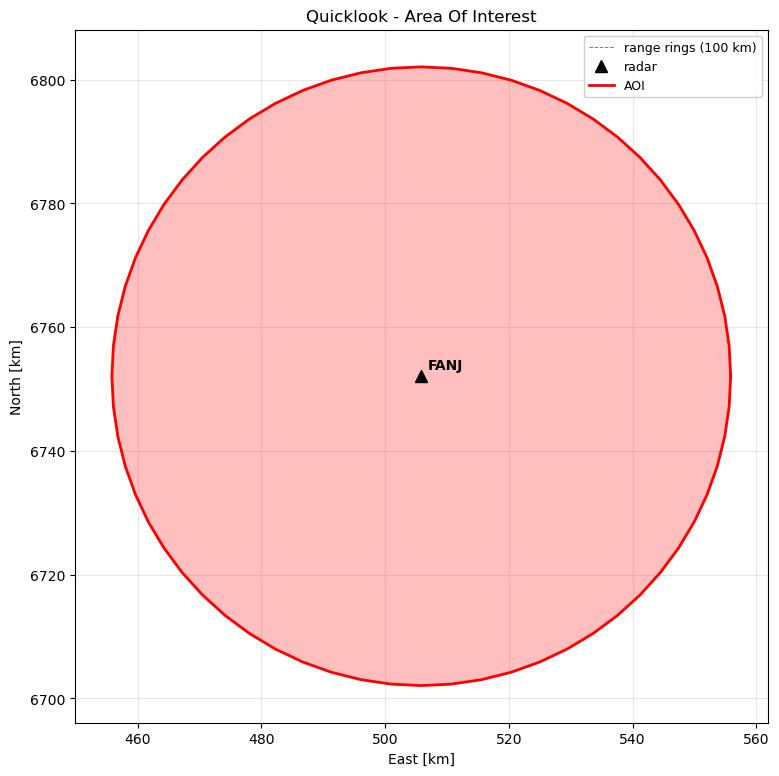

In [13]:
_ = rdf.crop_around_point(point=SITE, distance=50_000, crs=4326, quicklook=True)
plt.show()

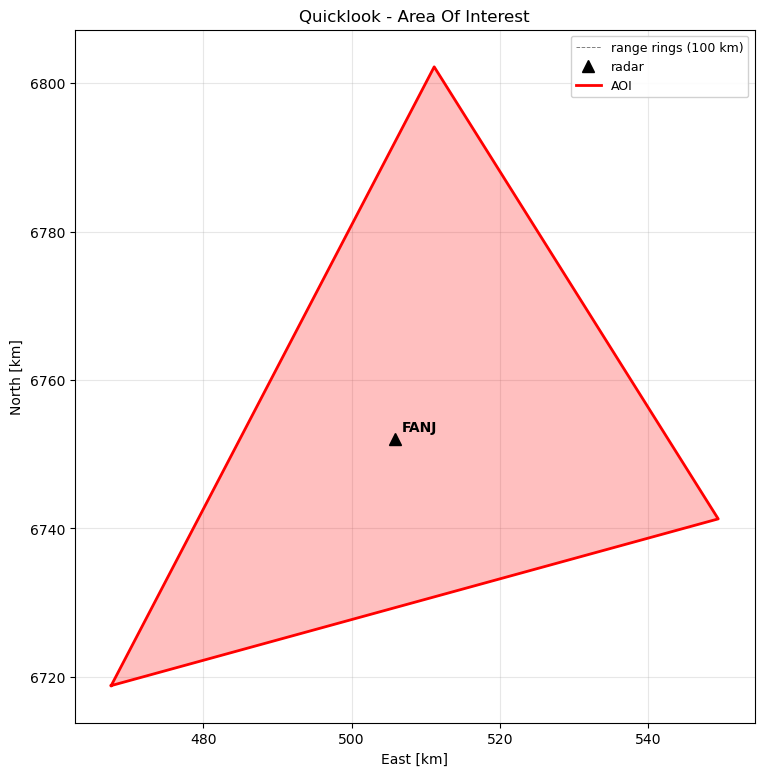

In [14]:
_ = rdf.crop_by_polygone(polygon=triangle, crs=4326, quicklook=True)
plt.show()

## 6. Chaining AOIs

Crops return a RadDB like everything else, so they compose with `filter` and `sel`
and with each other.

In [15]:
storm = (
    db.open(radars="FANJ")
    .filter({"var": "DBZH", "logic": ">", "threshold": 35})
    .crop_around_point(point=SITE, distance=60_000, crs=4326)
    .sel(range=slice(5_000, 60_000))
)
print(f"{len(storm):,} gates: strong echo, within 60 km, beyond 5 km range")

62,717 gates: strong echo, within 60 km, beyond 5 km range


## 7. The interactive tool

In Jupyter, `interactive_crop()` puts an [ipyleaflet](https://ipyleaflet.readthedocs.io/)
map in front of you: draw a shape with the toolbar, click **Apply crop**, and the
crop runs for you.

The tool dispatches on what you drew:

| you draw | RadDB runs |
|---|---|
| rectangle | `crop_by_bbox` |
| polygon | `crop_by_polygone` |
| marker | `crop_around_point`, using the **radius** box under the map |
| **polyline** | `extract_cross_section` |

It returns a **selector object**, and the crop lands on its attributes:

| attribute | what it holds |
|---|---|
| `selector.result` | the cropped **RadDB** — the same object any `crop_*` returns, so it filters, plots and converts like the rest of this notebook |
| `selector.kind` | which crop ran: `'bbox'`, `'polygon'`, `'point'` or `'cross_section'` |
| `selector.feature` | the shape you drew, as GeoJSON in lon/lat |

`selector.result` stays `None` until you press *Apply crop*, which is why drawing
and reading the result are split across the next two cells.

In [16]:
RUN_INTERACTIVE = True  # <- set False to skip the map (e.g. outside Jupyter)

if RUN_INTERACTIVE:
    # `selector` is the widget handle — the map appears immediately below.
    # Draw a shape with the toolbar, then click "Apply crop" before running the
    # next cell.  For a marker, set the radius box first; it is read on click.
    selector = rdf.interactive_crop()
else:
    selector = None
    print("interactive_crop() needs a live Jupyter kernel ==> set RUN_INTERACTIVE = True")

In [17]:
from IPython.display import display

# Run this cell *after* drawing a shape above and clicking "Apply crop".
# `cropped` is an ordinary RadDB: filter it, crop it again, plot it or convert it,
# exactly as in the sections above.  Until Apply crop is pressed it is still None.
if RUN_INTERACTIVE and selector is not None and selector.result is not None:
    cropped = selector.result  # <- the cropped RadDB
    print(f"{selector.kind} -> {len(cropped):,} gates")
    print("drawn shape :", selector.feature["geometry"]["type"])
    display(cropped.head())
else:
    print("nothing applied yet — draw a shape above, click 'Apply crop', then re-run this cell")

nothing applied yet — draw a shape above, click 'Apply crop', then re-run this cell


---
**Next:** [4 — Plots](04_plots.ipynb)